# 1.0 — Setup & Imports

Mount Google Drive and install any extra dependencies, then import all required libraries.

## 1.1 — Colab Environment Setup

Mounts Drive and installs `xlsxwriter`, `openpyxl`, and `tqdm` if running in Colab.

In [1]:
import os
import sys
import subprocess

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', 'xlsxwriter', 'openpyxl', 'tqdm'],
        check=True
    )

Mounted at /content/drive


## 1.2 — Library Imports

Standard library, third-party scientific stack, and TensorFlow/Keras.

In [2]:
# Standard library
import io
import json
import time
import random
import warnings
from pathlib import Path

from scipy.io import loadmat

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from openpyxl import load_workbook

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print('Python   :', sys.version.split()[0])
print('TensorFlow:', tf.__version__)

Python   : 3.12.13
TensorFlow: 2.20.0


# 2.0 — Configuration

All tunable constants, file paths, and hyperparameters in one place.  
Edit this section only — nothing else needs to change for a different run.

## 2.1 — Seeds, Paths & Data Geometry

Defines all I/O paths and dataset dimensions (auto-inferred from the .mat scene).

In [3]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path('/content/drive/My Drive/Classification')
DATA_DIR     = Path('/content/drive/My Drive/Classification/data')
MODEL_DIR    = Path('/content/drive/My Drive/Classification/baseline/models')
OUTPUT_DIR   = Path('/content/drive/My Drive/Classification/sacp/results')


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


DATA_FILE  = DATA_DIR / 'DIAS.mat'      # hyperspectral cube (H, W, Bands)
LABEL_FILE = DATA_DIR / 'DIAS_ref.mat'  # reference / ground-truth label map

MODEL_FILES = {
    'AlexNet_CNN': MODEL_DIR / 'AlexNet_CNN_best.keras',
    'GFNet':       MODEL_DIR / 'GFNet_best.keras',
    'ViT_UNet':    MODEL_DIR / 'ViT_UNet_best.keras',
}
MODEL_NAME_MAP = {
    'AlexNet_CNN': 'AlexNet',
    'GFNet':       'GFNet',
    'ViT_UNet':    'ViT',
}

TRUSTED_MODEL_ROOTS = [
    Path('/content/drive/My Drive/Classification/baseline/models'),
]

# Data geometry — H, W, B are inferred automatically from the .mat cube shape
# once loaded in Section 4.1, so this works unchanged for any scene/band count.
H, W, B    = None, None, None
PATCH_SIZE = 9
PERCENTILE_CLIP = (2.0, 98.0)  # robust per-band stretch range (2nd-98th percentile)
TRAIN_PERCENT          = 0.75
CALIB_FRACTION_OF_TEST = 0.5
BATCH_SIZE = 128
EPS        = 1e-12

## 2.2 — SACP Hyperparameters & Output Paths

All SACP-specific parameters and output file paths.

In [4]:
SACP_ALPHA        = 0.05
SACP_LAMBDA       = 0.5
SACP_K            = 1
SACP_WINDOW_SIZES = [3, 5, 7, 9]   # all window sizes to sweep

# Top-level combined outputs (written after all window loops finish)
COMBINED_SUMMARY_CSV  = OUTPUT_DIR / 'combined_summary_all_windows.csv'
COMBINED_PERCLASS_CSV = OUTPUT_DIR / 'combined_per_class_all_windows.csv'

for k, v in MODEL_FILES.items():
    print(f'{k}: {v}')
print('Output dir:', OUTPUT_DIR)
print('Window sizes to sweep:', SACP_WINDOW_SIZES)

AlexNet_CNN: /content/drive/My Drive/Classification/baseline/models/AlexNet_CNN_best.keras
GFNet: /content/drive/My Drive/Classification/baseline/models/GFNet_best.keras
ViT_UNet: /content/drive/My Drive/Classification/baseline/models/ViT_UNet_best.keras
Output dir: /content/drive/My Drive/Classification/sacp/results
Window sizes to sweep: [3, 5, 7, 9]


# 3.0 — Environment Guards

Validates that all required data and model files exist before any heavy computation starts.  
Raises a clear `FileNotFoundError` if anything is missing.

In [5]:
def assert_environment_and_files():
    """Raise FileNotFoundError early if data or model files are missing."""
    if not DATA_FILE.exists() or not LABEL_FILE.exists():
        raise FileNotFoundError(
            f'Data files missing:\n- {DATA_FILE}\n- {LABEL_FILE}'
        )
    missing = [str(p) for p in MODEL_FILES.values() if not p.exists()]
    if missing:
        raise FileNotFoundError('Missing model files:\n' + '\n'.join(missing))

assert_environment_and_files()
print('All required files found.')

All required files found.


# 4.0 — Data Pipeline

Loads multispectral imagery, extracts labeled patches with pixel coordinates,
then splits into train / calibration / evaluation sets.

## 4.1 — Loading & Normalisation

Reads the scene from .mat files as (H, W, B), and robustly percentile-stretches each band to [0, 1].

In [6]:
def load_scene_from_mat(data_path, label_path, data_key=None, label_key=None):
    """Load a hyperspectral/multispectral scene + reference labels from .mat files.

    Auto-detects the variable name inside each .mat file if not given (matches
    files such as DIAS.mat / DIAS_ref.mat storing the array under a single
    named variable). Each spectral band is robustly stretched to [0, 1] using
    a percentile clip (PERCENTILE_CLIP) rather than literal min/max — a handful
    of saturated/no-data pixels (e.g. sensor clipping at int8 range limits
    -128/127) would otherwise dominate the stretch.
    """
    def _first_array(mat_dict, key):
        if key is not None:
            return mat_dict[key]
        candidates = [v for k, v in mat_dict.items() if not k.startswith('__')]
        if not candidates:
            raise ValueError(f'No data arrays found in {mat_dict.keys()}')
        return candidates[0]

    data_mat  = loadmat(data_path)
    label_mat = loadmat(label_path)

    x = _first_array(data_mat, data_key).astype(np.float32)
    y = _first_array(label_mat, label_key).astype(np.int32)

    if x.ndim != 3:
        raise ValueError(f'Expected a (H, W, Bands) cube, got shape {x.shape}')
    if y.shape != x.shape[:2]:
        raise ValueError(f'Label shape {y.shape} does not match image shape {x.shape[:2]}')

    height, width, bands = x.shape

    x_norm = np.empty_like(x, dtype=np.float32)
    for bi in range(bands):
        band = x[:, :, bi]
        lo   = np.percentile(band, PERCENTILE_CLIP[0])
        hi   = np.percentile(band, PERCENTILE_CLIP[1])
        denom = max(hi - lo, 1e-8)
        band_clipped = np.clip(band, lo, hi)
        x_norm[:, :, bi] = (band_clipped - lo) / denom

    return x_norm, y, height, width, bands


x_img, y_img, H, W, B = load_scene_from_mat(DATA_FILE, LABEL_FILE)
print('Scene geometry: H=%d  W=%d  Bands=%d' % (H, W, B))
print('x_img:', x_img.shape, '| y_img:', y_img.shape)

x_img: (330, 307, 6) | y_img: (330, 307)


## 4.2 — Patch Extraction & Train/Calibration/Evaluation Split

Extracts (patch_size × patch_size) windows around every labeled pixel, records pixel coordinates, then stratified-splits into train / calibration / evaluation sets.

In [7]:
def extract_labeled_patches_with_coords(x_img, y_img, patch_size=9):
    """Extract patches centred on every labeled pixel; returns patches, labels, coords."""
    pad   = patch_size // 2
    x_pad = np.pad(x_img, ((pad, pad), (pad, pad), (0, 0)), mode='edge')

    coords    = np.argwhere(y_img > 0)
    x_patches = np.empty((coords.shape[0], patch_size, patch_size, x_img.shape[-1]), dtype=np.float32)
    y_labels  = np.empty((coords.shape[0],), dtype=np.int32)

    for i, (r, c) in enumerate(coords):
        x_patches[i] = x_pad[r:r + patch_size, c:c + patch_size, :]
        y_labels[i]  = int(y_img[r, c]) - 1  # 0-indexed classes

    return x_patches, y_labels, coords


def split_calib_eval_with_coords(x_test, y_test, coords_test, seed=42, calib_fraction=0.5):
    """Stratified split of the test pool into calibration and evaluation sets."""
    test_size = 1.0 - calib_fraction
    try:
        return train_test_split(
            x_test, y_test, coords_test,
            test_size=test_size, random_state=seed, stratify=y_test,
        )
    except ValueError:
        return train_test_split(
            x_test, y_test, coords_test,
            test_size=test_size, random_state=seed, stratify=None,
        )


X_all, y_all, coords_all = extract_labeled_patches_with_coords(x_img, y_img, PATCH_SIZE)
num_classes = int(np.unique(y_all).size)

_, x_test_pool, _, y_test_pool, _, coords_test_pool = train_test_split(
    X_all, y_all, coords_all,
    train_size=TRAIN_PERCENT, random_state=SEED, stratify=y_all,
)

x_cal, x_eval, y_cal, y_eval, coords_cal, coords_eval = split_calib_eval_with_coords(
    x_test_pool, y_test_pool, coords_test_pool,
    seed=SEED, calib_fraction=CALIB_FRACTION_OF_TEST,
)

print('X_all:', X_all.shape, '| num_classes:', num_classes)
print('x_cal:', x_cal.shape, '| x_eval:', x_eval.shape)
print('coords_cal:', coords_cal.shape, '| coords_eval:', coords_eval.shape)

X_all: (17239, 9, 9, 6) | num_classes: 7
x_cal: (2155, 9, 9, 6) | x_eval: (2155, 9, 9, 6)
coords_cal: (2155, 2) | coords_eval: (2155, 2)


# 5.0 — Custom Keras Layers

Registers the four custom layer classes required to deserialise the saved models.  
These must be defined before any `keras.models.load_model` call.

In [8]:
@tf.keras.utils.register_keras_serializable()
class PatchExtractor(layers.Layer):
    """Extracts non-overlapping image patches into a sequence."""

    def __init__(self, patch_size=3, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        b = tf.shape(images)[0]
        n = tf.shape(patches)[1] * tf.shape(patches)[2]
        d = tf.shape(patches)[-1]
        return tf.reshape(patches, [b, n, d])

    def get_config(self):
        c = super().get_config()
        c.update({'patch_size': self.patch_size})
        return c


@tf.keras.utils.register_keras_serializable()
class PatchPositionEncoder(layers.Layer):
    """Projects patches to projection_dim and adds learned position embeddings."""

    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches     = num_patches
        self.projection_dim  = projection_dim
        self.projection      = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patches):
        pos = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(pos)

    def get_config(self):
        c = super().get_config()
        c.update({'num_patches': self.num_patches, 'projection_dim': self.projection_dim})
        return c


@tf.keras.utils.register_keras_serializable()
class GlobalFilterLayer(layers.Layer):
    """Applies a learnable 2-D frequency filter via FFT (GFNet core block)."""

    def __init__(self, token_side, **kwargs):
        super().__init__(**kwargs)
        self.token_side = token_side

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.w_real = self.add_weight(
            name='w_real', shape=(self.token_side, self.token_side, channels),
            initializer='glorot_uniform', trainable=True,
        )
        self.w_imag = self.add_weight(
            name='w_imag', shape=(self.token_side, self.token_side, channels),
            initializer='zeros', trainable=True,
        )
        super().build(input_shape)

    def call(self, x):
        b  = tf.shape(x)[0]
        c  = tf.shape(x)[-1]
        x2 = tf.reshape(x, [b, self.token_side, self.token_side, c])
        x_fft = tf.signal.fft2d(tf.cast(x2, tf.complex64))
        w  = tf.complex(self.w_real, self.w_imag)
        x_i = tf.math.real(tf.signal.ifft2d(x_fft * w))
        return tf.reshape(x_i, [b, self.token_side * self.token_side, c])

    def get_config(self):
        c = super().get_config()
        c.update({'token_side': self.token_side})
        return c


@tf.keras.utils.register_keras_serializable()
class PatchEncoderWithCLS(layers.Layer):
    """Projects patches and prepends a learnable CLS token (ViT-style)."""

    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches    = num_patches
        self.projection_dim = projection_dim
        self.projection     = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches + 1, output_dim=projection_dim
        )

    def build(self, input_shape):
        self.cls_token = self.add_weight(
            name='cls_token', shape=(1, 1, self.projection_dim),
            initializer='zeros', trainable=True,
        )
        super().build(input_shape)

    def call(self, patches):
        b   = tf.shape(patches)[0]
        p   = self.projection(patches)
        cls = tf.repeat(self.cls_token, repeats=b, axis=0)
        x   = tf.concat([cls, p], axis=1)
        pos = tf.range(start=0, limit=self.num_patches + 1, delta=1)
        return x + self.position_embedding(pos)

    def get_config(self):
        c = super().get_config()
        c.update({'num_patches': self.num_patches, 'projection_dim': self.projection_dim})
        return c


CUSTOM_OBJECTS = {
    'PatchExtractor':       PatchExtractor,
    'PatchPositionEncoder': PatchPositionEncoder,
    'GlobalFilterLayer':    GlobalFilterLayer,
    'PatchEncoderWithCLS':  PatchEncoderWithCLS,
}

# 6.0 — Model Loading & Smoke Test

Loads all three saved Keras models with a path-trust check, then runs a
quick smoke-test prediction to verify shape and numerical validity.

In [9]:
def is_trusted_model_path(path: Path) -> bool:
    """Return True only if `path` is inside one of the pre-approved roots."""
    p = path.expanduser().resolve()
    for root in TRUSTED_MODEL_ROOTS:
        r = root.expanduser().resolve()
        if p == r or r in p.parents:
            return True
    return False


def load_models(model_files, custom_objects):
    """Load all models with fallback for Lambda-layer deserialization issues."""
    loaded = {}
    for key, path in model_files.items():
        path = Path(path)
        print(f'Loading {key} from {path}')

        if not is_trusted_model_path(path):
            raise RuntimeError(f'Untrusted model path: {path}')

        first_err = None
        try:
            m = keras.models.load_model(
                path, custom_objects=custom_objects, compile=False, safe_mode=False
            )
            loaded[key] = m
            print(f'  Loaded {key} successfully.')
            continue
        except Exception as e:
            first_err = e
            print(f'  Primary load failed for {key}: {e}')
            print('  Suggested checks: file integrity, custom_objects, TF/Keras versions.')

        # Fallback for safe_mode / Lambda-related failures
        lambda_related = 'lambda' in str(first_err).lower() or 'safe_mode' in str(first_err).lower()
        if lambda_related:
            try:
                keras.config.enable_unsafe_deserialization()
                m = keras.models.load_model(
                    path, custom_objects=custom_objects, compile=False, safe_mode=False
                )
                loaded[key] = m
                print(f'  Fallback load succeeded for {key}.')
                continue
            except Exception as second_err:
                raise RuntimeError(
                    f'Failed to load {key} from {path}.\n'
                    f'Primary error: {first_err}\nFallback error: {second_err}'
                )

        raise RuntimeError(f'Failed to load {key} from {path}. Error: {first_err}')

    return loaded


models = load_models(MODEL_FILES, CUSTOM_OBJECTS)

# Smoke test — verify output shape and numerical validity
x_smoke = x_eval[:8]
for key, model in models.items():
    p = model.predict(x_smoke, verbose=0)
    assert p.ndim == 2,               f'{key}: expected rank-2 output, got {p.shape}'
    assert p.shape[1] == num_classes, f'{key}: expected class dim {num_classes}, got {p.shape[1]}'
    assert np.isfinite(p).all(),      f'{key}: NaN/Inf in prediction output'
    print(key, 'smoke output shape:', p.shape)

Loading AlexNet_CNN from /content/drive/My Drive/Classification/baseline/models/AlexNet_CNN_best.keras
  Loaded AlexNet_CNN successfully.
Loading GFNet from /content/drive/My Drive/Classification/baseline/models/GFNet_best.keras
  Loaded GFNet successfully.
Loading ViT_UNet from /content/drive/My Drive/Classification/baseline/models/ViT_UNet_best.keras
  Loaded ViT_UNet successfully.
AlexNet_CNN smoke output shape: (8, 7)
GFNet smoke output shape: (8, 7)
ViT_UNet smoke output shape: (8, 7)


# 7.0 — SACP Utilities & Plotting Helpers

All helper functions and the `SpatialConformalPredictor` class.  
No business logic lives here — these are pure utilities consumed by Section 8.

## 7.1 — Score & Metric Helpers

Probability normalisation, APS score computation, set-metric aggregation, and per-class coverage summaries.

In [10]:
# ── Colour palette ──────────────────────────────────────────────────────────
# Same bold, saturated palette used across the other notebooks. Auto-extended
# with additional bold shades (same style, not muted tab20) if a future
# dataset has more than 10 classes.
import colorsys

CLASS_COLORS_BASE = [
    '#0000FF', '#00FF00', '#FF0000', '#00FFFF', '#FF00FF',
    '#FFFF00', '#A52A2A', '#FFA500', '#7FFF00', '#8A2BE2',
]
UNCERTAIN_COLOR = '#808080'


def _generate_extra_shades(n_extra, hue_offset=0.05, sat=0.85, val=0.95):
    """Bold, highly-saturated extra hues in the same style as CLASS_COLORS_BASE."""
    shades = []
    for i in range(n_extra):
        hue = (hue_offset + i / max(n_extra, 1)) % 1.0
        r, g, b = colorsys.hsv_to_rgb(hue, sat, val)
        shades.append('#%02x%02x%02x' % (int(r * 255), int(g * 255), int(b * 255)))
    return shades


def get_class_colors(n):
    """Return a list of `n` hex colour strings for class visualisation, extending
    the base 10 with additional bold shades in the same saturated style."""
    if n <= len(CLASS_COLORS_BASE):
        return CLASS_COLORS_BASE[:n]
    return CLASS_COLORS_BASE + _generate_extra_shades(n - len(CLASS_COLORS_BASE))


def resolve_uncertain_color(class_colors, preferred=UNCERTAIN_COLOR, min_dist=60):
    """Return `preferred` unless it visually clashes with any class colour, in
    which case fall back to a distinct dark slate so 'Uncertain' never collides
    with a real class colour."""
    def _hex_to_rgb(h):
        h = h.lstrip('#')
        return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))
    pr, pg, pb = _hex_to_rgb(preferred)
    for c in class_colors:
        cr, cg, cb = _hex_to_rgb(c)
        dist = ((pr - cr) ** 2 + (pg - cg) ** 2 + (pb - cb) ** 2) ** 0.5
        if dist < min_dist:
            return '#2F2F2F'
    return preferred


def normalize_probs(prob, eps=1e-12):
    """Clip, nan-guard, and L1-normalise a probability array along axis=-1."""
    prob = np.asarray(prob, dtype=np.float64)
    prob = np.nan_to_num(prob, nan=0.0, posinf=0.0, neginf=0.0)
    prob = np.clip(prob, 0.0, 1.0)
    rs   = prob.sum(axis=-1, keepdims=True)
    rs   = np.where(rs <= eps, 1.0, rs)
    return prob / rs


def predict_probs(model, x, batch_size=128):
    """Run model inference and return normalised softmax probabilities."""
    return normalize_probs(model.predict(x, batch_size=batch_size, verbose=0), eps=EPS)


def compute_set_metrics(pred_sets, y_true):
    """Aggregate coverage, set-size, and singleton/empty-set statistics."""
    pred_sets = pred_sets.astype(bool)
    set_sizes = pred_sets.sum(axis=1)
    covered   = pred_sets[np.arange(len(y_true)), y_true].astype(int)
    return {
        'empirical_coverage': float(np.mean(covered)),
        'avg_set_size':       float(np.mean(set_sizes)),
        'median_set_size':    float(np.median(set_sizes)),
        'singleton_rate':     float(np.mean(set_sizes == 1)),
        'empty_set_rate':     float(np.mean(set_sizes == 0)),
        'set_sizes':          set_sizes,
        'covered':            covered,
    }


def per_class_coverage_df(pred_sets, y_true, n_classes):
    """Return a DataFrame with per-class coverage and support counts."""
    rows = []
    for c in range(n_classes):
        mask    = (y_true == c)
        support = int(mask.sum())
        cov     = float(np.mean(pred_sets[mask, c])) if support > 0 else np.nan
        rows.append({'class_id': c, 'class_coverage': cov, 'support_count': support})
    return pd.DataFrame(rows)


def build_pixel_counts_df(combined_map, n_classes):
    """Count pixels per class (plus uncertain) from the combined classification map."""
    uniq, cnt = np.unique(combined_map, return_counts=True)
    m    = {int(k): int(v) for k, v in zip(uniq, cnt)}
    rows = [
        {'class_id': c, 'label': f'Class {c}', 'pixel_count': m.get(c, 0)}
        for c in range(n_classes)
    ]
    rows.append({'class_id': n_classes, 'label': 'Uncertain', 'pixel_count': m.get(n_classes, 0)})
    return pd.DataFrame(rows)

## 7.2 — Plotting Helpers

Four plot generators (per-class coverage, certain/uncertain map, masked class map, pixel-count bar) plus the figure-to-buffer utility.

In [11]:
def fig_to_buffer(fig):
    """Render a matplotlib figure to an in-memory PNG buffer and close it."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    buf.seek(0)
    plt.close(fig)
    return buf


def add_bar_labels(ax, fmt='{:.2f}', y_pad=0.01):
    """Annotate each bar in `ax` with its numeric height."""
    ymax = max(ax.get_ylim()[1], 1e-9)
    for p in ax.patches:
        h = p.get_height()
        if np.isnan(h):
            continue
        ax.text(
            p.get_x() + p.get_width() / 2, h + y_pad * ymax,
            fmt.format(h), ha='center', va='bottom', fontsize=9,
        )


def make_per_class_coverage_plot(per_cls_df, alpha, title):
    """Bar chart of per-class empirical coverage vs the target 1-alpha level."""
    fig, ax = plt.subplots(figsize=(15, 7))
    labels  = [f'Class {int(c)}' for c in per_cls_df['class_id']]
    vals    = per_cls_df['class_coverage'].to_numpy(dtype=float)
    ax.bar(labels, vals, edgecolor='black', color='skyblue')
    ax.axhline(1 - alpha, color='red', linestyle='--', linewidth=2,
               label=f'Desired Coverage ({1-alpha:.2f})')
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Class')
    ax.set_ylabel('Coverage')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.tick_params(axis='x', rotation=45)
    add_bar_labels(ax, fmt='{:.2f}', y_pad=0.01)
    ax.legend(loc='upper right')
    fig.tight_layout()
    return fig_to_buffer(fig)


def make_certain_uncertain_map_plot(set_sizes_map, title):
    """Binary spatial map: yellow = certain (set size 1), dark = uncertain."""
    disp = np.where(set_sizes_map == 1, 0, 1)
    cmap = ListedColormap(['#FFFF00', '#001F3F'])
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(disp, cmap=cmap)
    ax.set_title(title, fontsize=16)
    ax.axis('off')
    legend_handles = [
        Patch(facecolor='#FFFF00', edgecolor='black', label='Certain (Size=1)'),
        Patch(facecolor='#001F3F', edgecolor='black', label='Uncertain (Size!=1)'),
    ]
    ax.legend(handles=legend_handles, loc='upper left',
              bbox_to_anchor=(1.02, 1), borderaxespad=0.0, frameon=True)
    fig.tight_layout()
    return fig_to_buffer(fig)


def make_masked_class_map_plot(combined_map, n_classes, title):
    """False-colour map where uncertain pixels are shown in grey."""
    class_colors = get_class_colors(n_classes)
    cmap = ListedColormap(class_colors + [resolve_uncertain_color(class_colors)])
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(combined_map, cmap=cmap, vmin=0, vmax=n_classes)
    ax.set_title(title, fontsize=16)
    ax.axis('off')
    cbar = fig.colorbar(im, ax=ax, ticks=np.arange(n_classes + 1),
                        fraction=0.046, pad=0.04)
    cbar.set_ticklabels([f'Class {i}' for i in range(n_classes)] + ['Uncertain'])
    fig.tight_layout()
    return fig_to_buffer(fig)


def make_pixel_count_plot(pixel_counts_df, title, n_classes):
    """Bar chart of pixel counts per class and uncertain region."""
    class_colors = get_class_colors(n_classes)
    colors = class_colors + [resolve_uncertain_color(class_colors)]
    fig, ax = plt.subplots(figsize=(10, 6))
    labels  = pixel_counts_df['label'].tolist()
    counts  = pixel_counts_df['pixel_count'].tolist()
    ax.bar(labels, counts, color=colors[:len(labels)], edgecolor='black')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Number of Pixels')
    ax.set_title(title, fontsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ymax = max(counts) if counts else 1
    for i, v in enumerate(counts):
        ax.text(i, v + 0.01 * ymax, f'{int(v):,}', ha='center', va='bottom', fontsize=9)
    fig.tight_layout()
    return fig_to_buffer(fig)

## 7.3 — SpatialConformalPredictor

Core SACP class: computes APS conformity scores, spatially smooths them over a neighbourhood window, calibrates a coverage threshold `q_hat`, and produces prediction sets.

In [12]:
class SpatialConformalPredictor:
    """
    Spatial Adaptive Conformal Predictor (SACP).

    Calibrates prediction sets using spatially-smoothed APS scores on a 2-D
    pixel grid, then applies the learned threshold to evaluation pixels.
    """

    def __init__(self, height, width, num_classes,
                 lambda_=0.5, alpha=0.05, k=1, window_size=3, seed=42):
        self.H           = height
        self.W           = width
        self.num_classes = num_classes
        self.lmd         = lambda_
        self.alpha       = alpha
        self.k           = k
        self.window_size = window_size
        self.seed        = seed

        assert window_size >= 3 and window_size % 2 == 1, (
            f'window_size must be an odd integer >= 3, got {window_size}'
        )
        radius = window_size // 2
        # Pre-compute neighbourhood offsets (excludes centre pixel)
        self.neighbors = [
            (dr, dc)
            for dr in range(-radius, radius + 1)
            for dc in range(-radius, radius + 1)
            if not (dr == 0 and dc == 0)
        ]

    def compute_aps_scores(self, probabilities, labels=None):
        """
        Compute randomised APS conformity scores.

        If `labels` is provided, returns a 1-D score per sample (calibration).
        Otherwise returns the full (N, C) score matrix (inference).
        """
        n              = probabilities.shape[0]
        sorted_indices = np.argsort(probabilities, axis=1)[:, ::-1]
        sorted_probs   = np.take_along_axis(probabilities, sorted_indices, axis=1)
        cumsum         = np.cumsum(sorted_probs, axis=1)

        rng = np.random.default_rng(self.seed)
        U   = rng.random(n)

        if labels is not None:
            scores = np.zeros(n)
            for i in range(n):
                y    = int(labels[i])
                rank = int(np.where(sorted_indices[i] == y)[0][0])
                if rank == 0:
                    scores[i] = U[i] * sorted_probs[i, 0]
                else:
                    scores[i] = cumsum[i, rank - 1] + U[i] * sorted_probs[i, rank]
            return scores

        scores_matrix = np.zeros_like(probabilities)
        for i in range(n):
            scores_sorted    = np.zeros(self.num_classes)
            scores_sorted[0] = U[i] * sorted_probs[i, 0]
            scores_sorted[1:] = cumsum[i, :-1] + U[i] * sorted_probs[i, 1:]
            scores_matrix[i, sorted_indices[i]] = scores_sorted
        return scores_matrix

    def spatial_smoothing(self, score_map, mask_map):
        """One pass of spatial score smoothing over the neighbourhood window."""
        smoothed    = np.copy(score_map)
        H, W, C     = score_map.shape
        rows, cols  = np.where(mask_map)

        for r, c in zip(rows, cols):
            ori     = score_map[r, c]
            n_sum   = np.zeros(C)
            n_count = 0
            for dr, dc in self.neighbors:
                nr, nc = r + dr, c + dc
                if 0 <= nr < H and 0 <= nc < W and mask_map[nr, nc]:
                    n_sum   += score_map[nr, nc]
                    n_count += 1
            if n_count > 0:
                smoothed[r, c] = self.lmd * ori + self.lmd * (n_sum / n_count)
        return smoothed

    def fit_calibrate(self, calib_probs, calib_labels, calib_indices,
                      test_probs, test_indices):
        """
        Calibrate q_hat on calib set, then return prediction sets for test set.

        Returns
        -------
        pred_sets : ndarray of shape (N_test, num_classes), dtype bool
        q_hat     : float — the conformal threshold
        avg_size  : float — mean prediction-set size on the test split
        """
        calib_scores_mat = self.compute_aps_scores(calib_probs)
        test_scores_mat  = self.compute_aps_scores(test_probs)

        # Populate spatial score map
        score_map = np.zeros((self.H, self.W, self.num_classes), dtype=np.float64)
        mask_map  = np.zeros((self.H, self.W), dtype=bool)

        for i, (r, c) in enumerate(calib_indices):
            score_map[r, c] = calib_scores_mat[i]
            mask_map[r, c]  = True
        for i, (r, c) in enumerate(test_indices):
            score_map[r, c] = test_scores_mat[i]
            mask_map[r, c]  = True

        # Iterative spatial smoothing
        current_map = score_map
        for _ in range(self.k):
            current_map = self.spatial_smoothing(current_map, mask_map)

        # Calibration quantile
        fused_calib_scores = np.array([
            current_map[r, c, int(calib_labels[i])]
            for i, (r, c) in enumerate(calib_indices)
        ])
        n       = len(fused_calib_scores)
        q_level = np.ceil((n + 1) * (1 - self.alpha)) / n
        q_level = min(1.0, max(0.0, q_level))
        q_hat   = float(np.quantile(fused_calib_scores, q_level, method='higher'))

        # Build prediction sets
        pred_sets = np.zeros((len(test_indices), self.num_classes), dtype=bool)
        for i, (r, c) in enumerate(test_indices):
            pred_sets[i] = (current_map[r, c] <= q_hat)
            if not pred_sets[i].any():  # guarantee non-empty set
                pred_sets[i, int(np.argmin(current_map[r, c]))] = True

        avg_size = float(pred_sets.sum(axis=1).mean())
        return pred_sets, q_hat, avg_size

# 8.0 — Core SACP Pipeline

Runs the full SACP workflow for every model: probability inference, conformal
calibration, full-scene visualisation, and metric collection.

## 8.1 — Full-Scene Inference

Predicts class probabilities for every pixel in the full (H × W) image by sliding a patch window column by column.

In [13]:
def predict_full_scene_probs(model, x_img, H, W, B, patch_size, batch_size=128):
    """
    Generate per-pixel softmax probabilities for the entire scene.

    Processes one column of pixels at a time to keep memory bounded.
    Logs progress every 50 columns.
    """
    pad   = patch_size // 2
    x_pad = np.pad(x_img, ((pad, pad), (pad, pad), (0, 0)), mode='edge')

    # Infer number of classes from a single test patch
    test_patch = x_pad[0:patch_size, 0:patch_size, :][None, ...]
    n_classes  = predict_probs(model, test_patch, batch_size=1).shape[1]

    prob_full = np.zeros((H, W, n_classes), dtype=np.float32)
    for col in range(W):
        patchs = np.zeros((H, patch_size, patch_size, B), dtype=np.float32)
        for row in range(H):
            patchs[row] = x_pad[row:row + patch_size, col:col + patch_size, :]
        prob_col          = predict_probs(model, patchs, batch_size=batch_size)
        prob_full[:, col, :] = prob_col
        if (col + 1) % 50 == 0 or (col + 1) == W:
            print(f'  full-scene progress: {col + 1}/{W}')

    assert prob_full.shape == (H, W, n_classes)
    return prob_full

## 8.2 — Per-Model SACP Runner

Orchestrates calibration, evaluation, full-scene map generation, and output packaging for a single model.

In [14]:
def build_sacp_outputs_for_model(
    model_name, model,
    x_cal, y_cal, coords_cal,
    x_eval, y_eval, coords_eval,
    x_img, alpha, lambda_, k, window_size=3, batch_size=128,
):
    """
    Run the complete SACP pipeline for one model.

    Returns a dict containing the summary row, per-class DataFrame,
    plot image buffers, and table DataFrames for Excel export.
    """
    t0 = time.perf_counter()

    # ── 1. Inference on calibration & evaluation splits ─────────────────────
    calib_probs = predict_probs(model, x_cal,  batch_size=batch_size)
    eval_probs  = predict_probs(model, x_eval, batch_size=batch_size)

    # ── 2. SACP calibration ──────────────────────────────────────────────────
    sacp = SpatialConformalPredictor(
        height=H, width=W, num_classes=num_classes,
        lambda_=lambda_, alpha=alpha, k=k, window_size=window_size, seed=SEED,
    )
    pred_sets_eval, q_hat, avg_size = sacp.fit_calibrate(
        calib_probs=calib_probs, calib_labels=y_cal, calib_indices=coords_cal,
        test_probs=eval_probs,   test_indices=coords_eval,
    )

    metrics  = compute_set_metrics(pred_sets_eval, y_eval)
    per_cls  = per_class_coverage_df(pred_sets_eval, y_eval, num_classes)

    # ── 3. Full-scene visualisation ──────────────────────────────────────────
    print(f'Generating full-scene probabilities for {model_name} ...')
    prob_full   = predict_full_scene_probs(
        model, x_img, H, W, B, PATCH_SIZE, batch_size=batch_size
    )

    flat_probs  = prob_full.reshape(-1, num_classes)
    flat_scores = sacp.compute_aps_scores(flat_probs)
    current_map = flat_scores.reshape(H, W, num_classes)

    if k > 0:
        mask_map_full = np.ones((H, W), dtype=bool)
        iterator = (
            tqdm(range(k), desc=f'Smoothing full map ({model_name})')
            if k > 1 else range(k)
        )
        for _ in iterator:
            current_map = sacp.spatial_smoothing(current_map, mask_map_full)

    pred_sets_full  = (current_map <= q_hat)
    set_sizes_map   = np.sum(pred_sets_full, axis=2)
    pred_class_map  = np.argmax(prob_full, axis=2)
    combined_map    = np.where(set_sizes_map == 1, pred_class_map, num_classes)
    pixel_counts_df = build_pixel_counts_df(combined_map, num_classes)

    # ── 4. Plot buffers ──────────────────────────────────────────────────────
    plot_buffers = {
        'Per-Class Coverage': make_per_class_coverage_plot(
            per_cls, alpha=alpha,
            title='SACP: Per-Class Coverage (Full Image)',
        ),
        'Certain vs Uncertain Map': make_certain_uncertain_map_plot(
            set_sizes_map,
            title=f'Predictions with 95% Uncertainty Map\n(SACP — {model_name})',
        ),
        'Class Map with Uncertain Mask': make_masked_class_map_plot(
            combined_map, n_classes=num_classes,
            title=f'Predictions with 95% Uncertainty Mask\n(SACP — {model_name})',
        ),
        'Pixel Counts': make_pixel_count_plot(
            pixel_counts_df,
            title='Pixel Count per Class (Including Uncertain Regions)',
            n_classes=num_classes,
        ),
    }

    runtime = time.perf_counter() - t0
    summary = {
        'model_name':           model_name,
        'method':               'SACP',
        'window_size':          int(window_size),
        'target_coverage':      float(1.0 - alpha),
        'empirical_coverage':   metrics['empirical_coverage'],
        'avg_set_size':         metrics['avg_set_size'],
        'median_set_size':      metrics['median_set_size'],
        'singleton_rate':       metrics['singleton_rate'],
        'empty_set_rate':       metrics['empty_set_rate'],
        'runtime_sec':          float(runtime),
        'alpha':                float(alpha),
        'lambda':               float(lambda_),
        'k':                    int(k),
        'q_hat':                float(q_hat),
        'mean_per_class_coverage': float(per_cls['class_coverage'].mean(skipna=True)),
    }
    tables = {
        'Summary':                pd.DataFrame([summary]),
        'Per-Class Coverage Values': per_cls,
        'Pixel Counts':           pixel_counts_df,
        'SACP Parameters':        pd.DataFrame([{
            'q_hat': float(q_hat), 'alpha': float(alpha),
            'lambda': float(lambda_), 'k': int(k),
            'avg_set_size_eval': float(avg_size),
        }]),
    }
    return {
        'model_name':    model_name,
        'summary':       summary,
        'per_class_df':  per_cls,
        'plot_buffers':  plot_buffers,
        'tables':        tables,
    }

## 8.3 — Window-Size Sweep Loop

Outer loop over `SACP_WINDOW_SIZES = [3, 5, 7, 9]`. For each window size it:
1. Creates a dedicated subfolder `results/window_<ws>/`
2. Runs SACP for all 3 models
3. Generates the per-window comparison plot
4. Saves the Excel workbook, summary CSV, per-class CSV, and run-config JSON

Export helper functions used inside the loop are defined in Section 8.4 below — **run cell 35 before cell 36**.

## 8.4 — Export Helper Functions

Sheet-name sanitisation, image insertion, and per-model sheet writer used inside the window-size loop.

In [15]:
# ── Sheet-name helpers ──────────────────────────────────────────────────────
def sanitize_sheet_name(name):
    """Replace characters forbidden in Excel sheet names and truncate to 31 chars."""
    for ch in ['\\', '/', '*', '?', ':', '[', ']']:
        name = name.replace(ch, '_')
    return name[:31]


def make_sheet_name(base, used):
    """Return a unique, sanitised sheet name and register it in `used`."""
    base      = sanitize_sheet_name(base)
    candidate = base
    i = 1
    while candidate in used:
        suffix    = f'_{i}'
        candidate = base[:31 - len(suffix)] + suffix
        i        += 1
    used.add(candidate)
    return candidate


def insert_buffer_image(ws, row, col, img_buf, x_scale=0.8, y_scale=0.8):
    """Insert a PNG buffer as an embedded image into an xlsxwriter worksheet."""
    img_buf.seek(0)
    ws.insert_image(row, col, 'plot.png',
                    {'image_data': img_buf, 'x_scale': x_scale, 'y_scale': y_scale})


def write_model_sheet(writer, workbook, output, sheet_name):
    """Write tables (left) and plots (right) for a single model into one sheet."""
    ws = workbook.add_worksheet(sheet_name)
    writer.sheets[sheet_name] = ws
    ws.write(0, 0, f"SACP - {output['model_name']}")

    row = 2
    for tname, tdf in output['tables'].items():
        ws.write(row, 0, tname)
        tdf.to_excel(writer, sheet_name=sheet_name,
                     startrow=row + 1, startcol=0, index=False)
        row += len(tdf) + 4

    img_row, img_col = 0, 9
    for pname, pbuf in output['plot_buffers'].items():
        ws.write(img_row, img_col, pname)
        insert_buffer_image(ws, img_row + 1, img_col, pbuf,
                            x_scale=0.75, y_scale=0.75)
        img_row += 24

In [16]:
# ── Accumulators for the cross-window summary (used in Cell 9.0) ─────────────
all_windows_summaries  = []   # ← FIX 1: initialize before the loop
all_windows_per_class  = []   # ← FIX 1: initialize before the loop

# ── Outer sweep over every window size ──────────────────────────────────────
for ws in SACP_WINDOW_SIZES:                        # ← FIX 2: outer loop was missing
    print(f"\n{'#'*60}")
    print(f"  WINDOW SIZE = {ws}")
    print(f"{'#'*60}")

    # Per-window output directory
    ws_dir = OUTPUT_DIR / f'window_{ws}'
    ws_dir.mkdir(parents=True, exist_ok=True)

    all_outputs = []

    for model_key, model in models.items():
        model_name = MODEL_NAME_MAP.get(model_key, model_key)
        print(f"\n{'='*20} Running SACP for {model_name} (ws={ws}) {'='*20}")

        out = build_sacp_outputs_for_model(
            model_name=model_name,
            model=model,
            x_cal=x_cal,       y_cal=y_cal,       coords_cal=coords_cal,
            x_eval=x_eval,     y_eval=y_eval,     coords_eval=coords_eval,
            x_img=x_img,
            alpha=SACP_ALPHA,
            lambda_=SACP_LAMBDA,
            k=SACP_K,
            window_size=ws,     # ← FIX 3: use the loop variable (int), not the list
            batch_size=BATCH_SIZE,
        )
        all_outputs.append(out)

    # ── Per-window summary & per-class DataFrames ────────────────────────────
    summary_df = (
        pd.DataFrame([o['summary'] for o in all_outputs])
        .sort_values('model_name')
        .reset_index(drop=True)
    )
    per_class_df = pd.concat(
        [o['per_class_df'].assign(model_name=o['model_name'], window_size=ws)
         for o in all_outputs],
        ignore_index=True,
    )

    # ── Save per-window CSVs ─────────────────────────────────────────────────
    summary_df.to_csv(ws_dir / f'summary_ws{ws}.csv', index=False)
    per_class_df.to_csv(ws_dir / f'per_class_ws{ws}.csv', index=False)

    # ── Save per-window Excel workbook ───────────────────────────────────────
    excel_path = ws_dir / f'conformal_reports_SACP_ws{ws}_all_models.xlsx'
    with pd.ExcelWriter(excel_path, engine='xlsxwriter') as writer:
            workbook = writer.book
            used_names = set()

            # ── Per-model sheets ─────────────────────────────────────────────────
            for out in all_outputs:
                sname = make_sheet_name(f"SACP_{out['model_name']}", used_names)
                write_model_sheet(writer, workbook, out, sname)

            # ── Summary_Compact sheet ────────────────────────────────────────────
            summary_df.to_excel(
                writer,
                sheet_name=make_sheet_name('Summary_Compact', used_names),
                index=False,
            )

            # ── Run_Config sheet ─────────────────────────────────────────────────
            pd.DataFrame([{
                'window_size': ws, 'alpha': SACP_ALPHA,
                'lambda': SACP_LAMBDA, 'k': SACP_K,
            }]).to_excel(
                writer,
                sheet_name=make_sheet_name('Run_Config', used_names),
                index=False,
            )

            # ── Compare_SACP sheet (was missing — fixes AssertionError) ──────────
            compare_cols = [
                'model_name', 'window_size',
                'empirical_coverage', 'avg_set_size', 'median_set_size',
                'singleton_rate', 'empty_set_rate',
                'mean_per_class_coverage', 'q_hat', 'runtime_sec',
            ]
            compare_df = summary_df[[c for c in compare_cols if c in summary_df.columns]]
            compare_sheet = make_sheet_name('Compare_SACP', used_names)
            compare_df.to_excel(writer, sheet_name=compare_sheet, index=False)

            # Optional: auto-widen columns for readability
            ws_xl = writer.sheets[compare_sheet]
            for i, col in enumerate(compare_df.columns):
                width = max(len(str(col)), compare_df[col].astype(str).str.len().max()) + 2
                ws_xl.set_column(i, i, width)
    print(f'Saved workbook: {excel_path}')

    # ── Accumulate for cross-window summary (Cell 9.0) ──────────────────────
    all_windows_summaries.append(summary_df)                         # ← FIX 4: populate
    all_windows_per_class.append(per_class_df)                       # ← FIX 4: populate

print("\n✓ All window sizes complete.")


############################################################
  WINDOW SIZE = 3
############################################################

==================== Running SACP for AlexNet (ws=3) ====================
Generating full-scene probabilities for AlexNet ...
  full-scene progress: 50/307
  full-scene progress: 100/307
  full-scene progress: 150/307
  full-scene progress: 200/307
  full-scene progress: 250/307
  full-scene progress: 300/307
  full-scene progress: 307/307

==================== Running SACP for GFNet (ws=3) ====================
Generating full-scene probabilities for GFNet ...
  full-scene progress: 50/307
  full-scene progress: 100/307
  full-scene progress: 150/307
  full-scene progress: 200/307
  full-scene progress: 250/307
  full-scene progress: 300/307
  full-scene progress: 307/307

==================== Running SACP for ViT (ws=3) ====================
Generating full-scene probabilities for ViT ...
  full-scene progress: 50/307
  full-scene progress: 100/3

# 9.0 — Combined Cross-Window Summary

After all window sizes have run, assemble a single combined summary (12 rows:
4 window sizes × 3 models) and generate a cross-window comparison plot.

Saved combined summary csv  : /content/drive/My Drive/Classification/sacp/results/combined_summary_all_windows.csv
Saved combined per-class csv: /content/drive/My Drive/Classification/sacp/results/combined_per_class_all_windows.csv


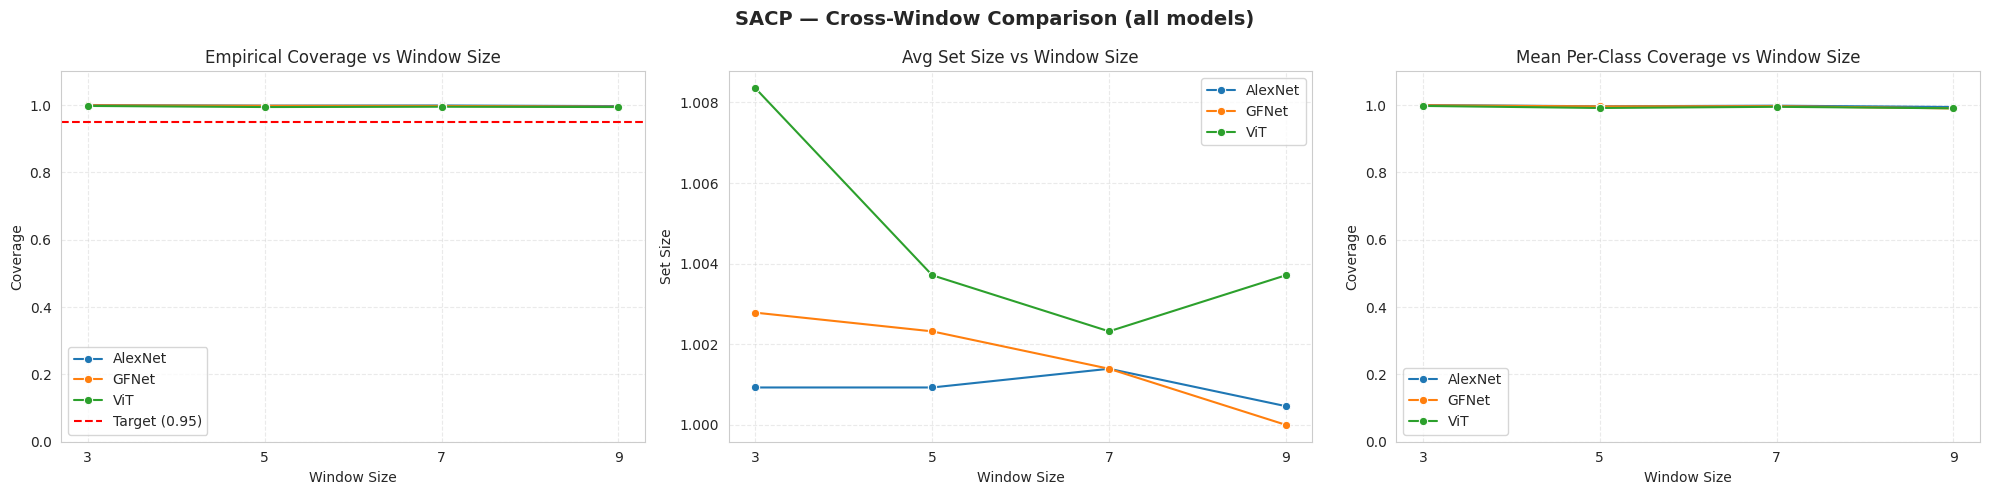

,model_name,method,window_size,target_coverage,empirical_coverage,avg_set_size,median_set_size,singleton_rate,empty_set_rate,runtime_sec,alpha,lambda,k,q_hat,mean_per_class_coverage
0,AlexNet,SACP,3,0.95,1.000000,1.000928,1.0,0.999072,0.0,51.893246,0.05,0.5,1,0.852016,1.000000
1,GFNet,SACP,3,0.95,0.999072,1.002784,1.0,0.997216,0.0,50.155808,0.05,0.5,1,0.847571,0.999202
2,ViT,SACP,3,0.95,0.997216,1.008353,1.0,0.993503,0.0,62.917061,0.05,0.5,1,0.824155,0.997245
3,AlexNet,SACP,5,0.95,0.998144,1.000928,1.0,0.999072,0.0,50.373631,0.05,0.5,1,0.768231,0.996213
4,GFNet,SACP,5,0.95,0.997680,1.002320,1.0,0.997680,0.0,45.494858,0.05,0.5,1,0.766427,0.995814
5,ViT,SACP,5,0.95,0.993968,1.003712,1.0,0.996288,0.0,50.523260,0.05,0.5,1,0.744368,0.991171
6,AlexNet,SACP,7,0.95,0.998608,1.001392,1.0,0.998608,0.0,55.113319,0.05,0.5,1,0.763558,0.998012
7,GFNet,SACP,7,0.95,0.997216,1.001392,1.0,0.998608,0.0,51.802607,0.05,0.5,1,0.757729,0.996572
8,ViT,SACP,7,0.95,0.994896,1.002320,1.0,0.997680,0.0,55.768648,0.05,0.5,1,0.733878,0.994659
9,AlexNet,SACP,9,0.95,0.996752,1.000464,1.0,0.999536,0.0,60.279493,0.05,0.5,1,0.770823,0.994067


In [17]:
# ── Concatenate all per-window summaries ─────────────────────────────────────
combined_summary_df   = pd.concat(all_windows_summaries,  ignore_index=True)
combined_per_class_df = pd.concat(all_windows_per_class,  ignore_index=True)

combined_summary_df.to_csv(COMBINED_SUMMARY_CSV,  index=False)
combined_per_class_df.to_csv(COMBINED_PERCLASS_CSV, index=False)
print('Saved combined summary csv  :', COMBINED_SUMMARY_CSV)
print('Saved combined per-class csv:', COMBINED_PERCLASS_CSV)

# ── Cross-window comparison plot (coverage & set-size vs window size) ─────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('SACP — Cross-Window Comparison (all models)', fontsize=14, fontweight='bold')

sns.lineplot(data=combined_summary_df, x='window_size', y='empirical_coverage',
             hue='model_name', marker='o', ax=axes[0])
axes[0].axhline(1 - SACP_ALPHA, linestyle='--', color='red', linewidth=1.5,
                label=f'Target ({1-SACP_ALPHA:.2f})')
axes[0].set_title('Empirical Coverage vs Window Size')
axes[0].set_xlabel('Window Size'); axes[0].set_ylabel('Coverage')
axes[0].set_ylim(0, 1.1)
axes[0].set_xticks(SACP_WINDOW_SIZES)
axes[0].legend()
axes[0].grid(linestyle='--', alpha=0.4)

sns.lineplot(data=combined_summary_df, x='window_size', y='avg_set_size',
             hue='model_name', marker='o', ax=axes[1])
axes[1].set_title('Avg Set Size vs Window Size')
axes[1].set_xlabel('Window Size'); axes[1].set_ylabel('Set Size')
axes[1].set_xticks(SACP_WINDOW_SIZES)
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.4)

mean_pc_all = (
    combined_summary_df
    .groupby(['window_size', 'model_name'], as_index=False)['mean_per_class_coverage']
    .mean()
)
sns.lineplot(data=mean_pc_all, x='window_size', y='mean_per_class_coverage',
             hue='model_name', marker='o', ax=axes[2])
axes[2].set_title('Mean Per-Class Coverage vs Window Size')
axes[2].set_xlabel('Window Size'); axes[2].set_ylabel('Coverage')
axes[2].set_ylim(0, 1.1)
axes[2].set_xticks(SACP_WINDOW_SIZES)
axes[2].legend()
axes[2].grid(linestyle='--', alpha=0.4)

fig.tight_layout()
plt.show()

combined_summary_df

# 10.0 — Final Validation

Verifies that every per-window folder contains the expected Excel workbook,
and that the combined summary has the correct number of rows.

In [18]:
# ── Per-window workbook checks ───────────────────────────────────────────────
for ws in SACP_WINDOW_SIZES:
    ws_dir     = OUTPUT_DIR / f'window_{ws}'
    excel_path = ws_dir / f'conformal_reports_SACP_ws{ws}_all_models.xlsx'
    assert excel_path.exists(), f'Missing workbook for window_size={ws}: {excel_path}'

    wb_check = load_workbook(excel_path, read_only=True)
    sheets   = set(wb_check.sheetnames)
    required_prefixes = {
        'Summary_Compact', 'Run_Config',
        'SACP_AlexNet', 'SACP_GFNet', 'SACP_ViT',
        'Compare_SACP',
    }
    for req in required_prefixes:
        assert any(s.startswith(req) for s in sheets), (
            f'[ws={ws}] Missing sheet: {req}'
        )
    print(f'[ws={ws}] Workbook OK — sheets: {sorted(sheets)}')

# ── Combined summary checks ──────────────────────────────────────────────────
expected_rows = len(SACP_WINDOW_SIZES) * len(MODEL_FILES)   # 4 × 3 = 12
assert len(combined_summary_df) == expected_rows, (
    f'Expected {expected_rows} rows in combined summary, got {len(combined_summary_df)}'
)
assert ((combined_summary_df['empirical_coverage'] >= 0) &
        (combined_summary_df['empirical_coverage'] <= 1)).all(), (
    'Coverage values outside [0, 1]'
)
assert set(combined_summary_df['window_size'].unique()) == set(SACP_WINDOW_SIZES), (
    'Not all window sizes present in combined summary'
)

# ── Pixel-count integrity per window ─────────────────────────────────────────
for ws_summary in all_windows_summaries:
    ws_val = int(ws_summary['window_size'].iloc[0])
    # Pixel counts are validated inside build_sacp_outputs_for_model already,
    # but re-check the combined per-class coverage is non-null
    ws_pc = combined_per_class_df[combined_per_class_df['window_size'] == ws_val]
    assert ws_pc['class_coverage'].notna().any(), (
        f'All per-class coverage NaN for window_size={ws_val}'
    )

print('\nAll validations passed.')
combined_summary_df

[ws=3] Workbook OK — sheets: ['Compare_SACP', 'Run_Config', 'SACP_AlexNet', 'SACP_GFNet', 'SACP_ViT', 'Summary_Compact']
[ws=5] Workbook OK — sheets: ['Compare_SACP', 'Run_Config', 'SACP_AlexNet', 'SACP_GFNet', 'SACP_ViT', 'Summary_Compact']
[ws=7] Workbook OK — sheets: ['Compare_SACP', 'Run_Config', 'SACP_AlexNet', 'SACP_GFNet', 'SACP_ViT', 'Summary_Compact']
[ws=9] Workbook OK — sheets: ['Compare_SACP', 'Run_Config', 'SACP_AlexNet', 'SACP_GFNet', 'SACP_ViT', 'Summary_Compact']

All validations passed.


,model_name,method,window_size,target_coverage,empirical_coverage,avg_set_size,median_set_size,singleton_rate,empty_set_rate,runtime_sec,alpha,lambda,k,q_hat,mean_per_class_coverage
0,AlexNet,SACP,3,0.95,1.000000,1.000928,1.0,0.999072,0.0,51.893246,0.05,0.5,1,0.852016,1.000000
1,GFNet,SACP,3,0.95,0.999072,1.002784,1.0,0.997216,0.0,50.155808,0.05,0.5,1,0.847571,0.999202
2,ViT,SACP,3,0.95,0.997216,1.008353,1.0,0.993503,0.0,62.917061,0.05,0.5,1,0.824155,0.997245
3,AlexNet,SACP,5,0.95,0.998144,1.000928,1.0,0.999072,0.0,50.373631,0.05,0.5,1,0.768231,0.996213
4,GFNet,SACP,5,0.95,0.997680,1.002320,1.0,0.997680,0.0,45.494858,0.05,0.5,1,0.766427,0.995814
5,ViT,SACP,5,0.95,0.993968,1.003712,1.0,0.996288,0.0,50.523260,0.05,0.5,1,0.744368,0.991171
6,AlexNet,SACP,7,0.95,0.998608,1.001392,1.0,0.998608,0.0,55.113319,0.05,0.5,1,0.763558,0.998012
7,GFNet,SACP,7,0.95,0.997216,1.001392,1.0,0.998608,0.0,51.802607,0.05,0.5,1,0.757729,0.996572
8,ViT,SACP,7,0.95,0.994896,1.002320,1.0,0.997680,0.0,55.768648,0.05,0.5,1,0.733878,0.994659
9,AlexNet,SACP,9,0.95,0.996752,1.000464,1.0,0.999536,0.0,60.279493,0.05,0.5,1,0.770823,0.994067
